In [22]:
from dotenv import load_dotenv
import requests
from agents import Agent, Runner, trace, function_tool, ModelSettings
from agents.extensions.visualization import draw_graph
from openai.types.responses import ResponseTextDeltaEvent
import os
import asyncio
import smtplib
from email.message import EmailMessage


The library is `openai-agents` (OpenAI's Agents SDK), imported in Python as `agents`. It's installed via `pip install openai-agents`.


In [23]:
import os
from dotenv import load_dotenv

load_dotenv("/Users/nareshchaurasia/nc/PYTHON-ARCHITECT/Python-Immersive-AI-MAC/.env_rag")

api_key = os.getenv("CO_API_KEY")
print(api_key)

cohere_TdqUeFRaqtfoO0Xq86sntO3dMBZ12T3hnQYJ84rT2SYr1u


In [24]:
#load_dotenv(override=True)
MODEL_NAME = "gpt-5.4-mini"
MODEL_NAME_DUMMY = "gpt-5.4-mi"

In [25]:
# This __replaces__ the default OpenAI-backend processor with LangSmith's, so traces get sent to your LangSmith project instead of `platform.openai.com/traces`.

from langsmith.wrappers import OpenAIAgentsTracingProcessor
from agents import set_trace_processors

set_trace_processors([OpenAIAgentsTracingProcessor()])

In [26]:
# Testing that tracking is working fine.
from langsmith import Client
client = Client()
print(client.list_projects(limit=1))  # should not raise 401 if key is valid

<generator object Client.list_projects at 0x1105ada80>


In [27]:
def send_email(message):
    print("send mail::"+message)

In [28]:
def send_message(message):
    send_email(message)


In [29]:
send_message("Big news")

send mail::Big news


In [ ]:
intro = """
You are a sales agent working for ComplAI, 
a company that provides a SaaS tool for ensuring SOC2 compliance and preparing for audits, powered by AI.
You write emails.
"""

instructions1 = intro + "Your email style is professional, serious, with gravitas and credibility."
instructions2 = intro + "Your email style is witty, engaging, and humorous."
instructions3 = intro + "Your email style is concise, to the point, in the style of a busy senior executive."

In [ ]:
sales_agent1 = Agent(name="Professional Sales Agent", instructions=instructions1, model=MODEL_NAME)
sales_agent2 = Agent(name="Humorous Sales Agent", instructions=instructions2, model=MODEL_NAME)
sales_agent3 = Agent(name="Executive Sales Agent", instructions=instructions3, model=MODEL_NAME)


In [ ]:
print(type(sales_agent1))

### Python Decorators - Creating Tools that Agent can use.

`@function_tool`

`@function_tool` is a **decorator** that converts a regular Python function into a **tool** that an AI agent can discover and call automatically.

Without `@function_tool`

The function is a normal Python function and can only be called explicitly in your code.

```python
def send_email_tool(message: str):
    send_message(message)
```

With `@function_tool`

The function becomes available to the AI agent as a tool.

```python
@function_tool
def send_email_tool(message: str):
    """Send an email with the given message."""
    send_message(message)
```

What `@function_tool` Does

- Registers the function as an AI tool.
- Uses the function name as the tool name.
- Uses the docstring as the tool description.
- Uses type hints to understand the input parameters.
- Allows the AI agent to automatically invoke the function when appropriate.

**In short:** `@function_tool` exposes a Python function to an AI agent, enabling it to discover and execute the function based on the user's request.



In [30]:
@function_tool
def send_email_tool(message: str) -> str:
    """
    Send out an email with the given message
    """
    send_message(message)
    return "Email sent successfully"

### This has automatically been converted into a tool, with the boilerplate json created

In [31]:
send_email_tool.params_json_schema

{'properties': {'message': {'title': 'Message', 'type': 'string'}},
 'required': ['message'],
 'title': 'send_email_tool_args',
 'type': 'object',
 'additionalProperties': False}

Here's the difference between **handoff** and **non-handoff (tools-based)** orchestration in this notebook:

## Non-Handoff (Tools-based) — Section 3a: via Tools

**Flow:** `Sales Manager → Sales Writer Agents → Sales Manager → send_email_tool`

- The **Sales Manager** agent has 4 tools: `tool1`, `tool2`, `tool3` (each wrapping a sales writer agent via `.as_tool()`) and `send_email_tool`.
- The Sales Manager **calls each writer tool** to generate 3 email drafts, gets the results back, evaluates them itself, then **calls `send_email_tool`** to send the best one.
- **Control always returns** to the calling agent (Sales Manager) after each tool call.
- Pattern: **A → B → A** (the orchestrator agent delegates to sub-agents as tools, gets results back, and continues).

## Handoff-based — Section 3b: via Handoffs

**Flow:** `Sales Manager → Sales Writer Agents → Sales Sender (handoff)`

- The **Sales Manager** has 3 tools (`tool1`, `tool2`, `tool3`) to generate drafts, but **no `send_email_tool`**.
- Instead, it has a **handoff** to `sales_sender` agent.
- After generating all 3 drafts, the Sales Manager **hands off control** to the `sales_sender` agent, which then decides which email is best and sends it.
- **Control does NOT return** to the Sales Manager — the `sales_sender` agent takes over completely.
- Pattern: **A → B** (control passes across, not back).

## Key Differences Summarized

| Aspect | Tools (Non-Handoff) | Handoffs |
|--------|-------------------|----------|
| **Control flow** | A → B → A (returns) | A → B (transfers) |
| **Who evaluates & sends?** | The orchestrator (Sales Manager) | The delegated agent (Sales Sender) |
| **Implementation** | Sub-agents wrapped as `.as_tool()` | Agents listed in `handoffs=[...]` parameter |
| **Reliability** | More predictable (author's preference) | Author notes: "not a fan, seems unreliable" |
| **Use case** | Planning agent pattern where orchestrator needs final say | Delegation pattern where sub-agent takes full responsibility |

The author (Ed Donner) explicitly states in the markdown: *"I am not a fan of handoffs. They seem very unreliable. They're not used consistently by other frameworks. Behind the scenes, OpenAI Agents SDK has implemented these with Tools anyway."*

So the fundamental difference is: **tools return control to the caller** (enabling a hub-and-spoke pattern), while **handoffs transfer control permanently** to the receiving agent (enabling a chain/pipe pattern).

## Part 3: Orchestrating by LLMs

### 3a: via Tools

The simplest way to have 1 Agent choose to invoke another is by treating it as a tool call.

The OpenAI Agents SDK gives a very simple way to do this.

This works best when the flow is:

Agent A -> Agent B -> Agent A

And for the classic "Planning Agent" situation.

In [32]:
description = "Use this tool to write a sales email. In the input, just instruct it to write a sales email."


### So now we can gather all the tools together:

A tool for each of our 3 email-writing agents

And a tool for our function to send emails

In [ ]:
tool1 = sales_agent1.as_tool(tool_name="sales_email_writer_1", tool_description=description)
tool2 = sales_agent2.as_tool(tool_name="sales_email_writer_2", tool_description=description)
tool3 = sales_agent3.as_tool(tool_name="sales_email_writer_3", tool_description=description)

tools = [tool1, tool2, tool3, send_email_tool]

tools

## And now it's time for our Sales Manager - our planning agent

In [33]:
instructions = """
You are a Sales Manager at ComplAI. Your goal is to find the single best cold sales email using the sales_writer tools.
"""

task = """
Follow these steps:

1. Generate Drafts: Use each of the three sales_email_writer tools to generate different email drafts.
Just instruct each to write a sales email; no further details are needed.
Do not proceed until all three drafts are ready, one from each tool.
 
2. Evaluate and Select: Review the drafts and choose the single best email using your judgment of which one is most effective.
 
3. Use your tool to send the best email (and only the best email) to the user. Only send 1 email.
"""


In [34]:
sales_manager = Agent(name="Sales Manager", instructions=instructions, tools=tools, model=MODEL_NAME)

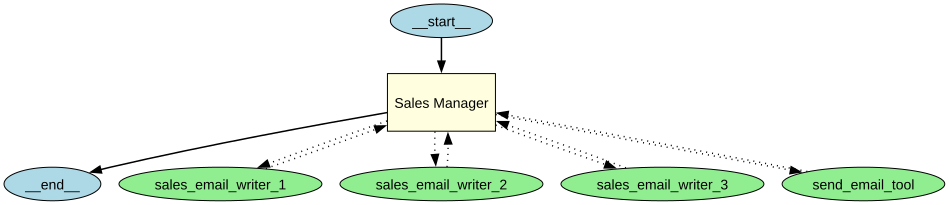

In [35]:
draw_graph(sales_manager)

In [39]:
with trace("Sales manager"):
    result = await Runner.run(sales_manager, task)

send mail::Subject: SOC 2 prep without the audit chaos

Hi [First Name],

If SOC 2 is on your roadmap, ComplAI can help you get audit-ready faster and with less manual work.

We use AI to:
- map controls to your environment
- identify gaps early
- organize evidence for auditors
- keep compliance work moving without heavy ops lift

Teams use ComplAI to cut down the back-and-forth, reduce prep time, and avoid surprise issues late in the process.

If helpful, I’d be glad to show you how it works in 15 minutes.

Best,
[Your Name]
ComplAI


## Remember to check the trace

https://platform.openai.com/traces

And then check your email!! Also look in your Junk / Spam folder - after all, this is basically a spam message..


## Part 3: Orchestrating by LLMs

### 3a: via Handoffs

I am not a fan of handoffs. They seem very unreliable. They're not used consistently by other frameworks.

Behind the scenes, OpenAI Agents SDK has implemented these with Tools anyway.

### Handoffs represent a way an agent can delegate to an agent, passing control to it

Handoffs and Agents-as-tools are similar:

In both cases, an Agent can collaborate with another Agent

With tools, control passes back

A -> B -> A

With handoffs, control passes across

A -> B

In [40]:
decision = """
You pick the best cold sales email from the given options.
Imagine you are a customer and pick the one you are most likely to respond to.
Then use your tool to send the email.
"""

require_tool = ModelSettings(tool_choice="required")

sales_sender = Agent(name="Sales Sender", instructions=decision, model=MODEL_NAME, tools=[send_email_tool], model_settings=require_tool)

In [41]:

instructions = """
You are a Sales Manager at ComplAI. You get your sales team to draft emails, then send them all to a sales picker.
"""

task = """
Follow these steps:

1. Generate Drafts: Use each of the three sales_email_writer tools to generate different email drafts.
Just instruct each to write a sales email; no further details are needed.
Do not proceed until all three drafts are ready, one from each tool.
 
2. Handoff to the sales sender to choose and send the best email.
"""

tools = [tool1, tool2, tool3]
handoffs = [sales_sender]

sales_manager = Agent(name="Sales Manager", instructions=instructions, tools=tools, handoffs=handoffs, model=MODEL_NAME)


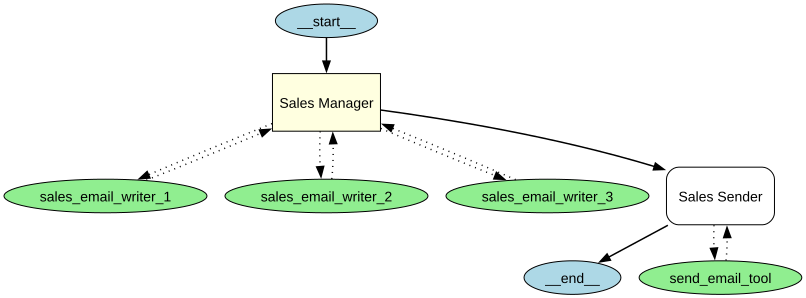

In [42]:
draw_graph(sales_manager)

In [ ]:
with trace("Sales manager"):
    result = await Runner.run(sales_manager, task)